# Machine Learning Exploration of Grid and Weather Data
This notebook gathers frequency, inertia, generation (fuel mix) and weather datasets and prepares them for machine learning. The goal is to spot patterns, detect grid events and understand relationships between generation, fuel mix and meteorological conditions. Several helper scripts in the repository document the structure of each source; they are imported below for reference.

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn for modelling (CPU versions)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

# detect GPU / RAPIDS availability
GPU_ENABLED = False
try:
    import cudf, dask_cudf
    import cuml
    GPU_ENABLED = True
    print("CUDA/RAPIDS available – GPU acceleration enabled")
except ImportError:
    print("RAPIDS libraries not found; running on CPU only")

# project-specific helpers (assumes sys.path includes parent folders)
import os, sys
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\Weather")
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\Frequency\Processors")
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\Inertia\Processors")
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\HistoricalGenerationData\Processors")
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\Random")
# additional data processors added after 2025
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\DemandData\Processors")
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\BalancingServices\Processors")
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data\GridwatchData\Processors")

print("Libraries imported")

RAPIDS libraries not found; running on CPU only
Libraries imported


## GPU acceleration

This notebook can optionally leverage NVIDIA GPUs via the RAPIDS
libraries (`cudf`, `dask_cudf`, `cuml`).  If the packages are installed
and a CUDA‑capable device is present, the variable `GPU_ENABLED` will be
set to `True` and subsequent data loading/modeling steps will use the
gpu‑accelerated implementations.  On a 16× RTX A4000 machine you can
process decades of per‑second data much faster.

To install RAPIDS in a compatible environment, follow the instructions at
https://rapids.ai/start or use a prebuilt conda package such as:

```bash
conda install -c rapidsai -c nvidia -c conda-forge \
    cudf cuml dask-cudf python=3.11
```

## Load Grid Events, Fuel Mix, and Weather Data
Read the pre‑processed parquet / CSV files for each dataset. The `df_fuel_ckan.csv` file holds half‑hourly generation values per fuel; the parquet directories contain partitioned frequency, inertia and weather observations.

> **This notebook is written to operate on the full archive of
> data** rather than a single year.  The loaders in `ml_pipeline` accept
> an optional `years` argument that defaults to `None` (meaning “all
> available partitions”).  Removing any hard‑coded year filters allows
> you to spot long‑term patterns without restricting yourself to 2014,
> 2020, or whatever the earliest row happens to be.

> If you’re experimenting with a subset for performance you can still
> pass `years=` explicitly, but the examples below show the wide‑view
> usage.


In [ ]:
import sys, os
sys.path.append(r"c:\Users\shir1\Documents\TSGB\Data")
from MachineLearning import ml_pipeline

# load the complete dataset; omit `years` to grab every partition
fuel_df = ml_pipeline.load_generation(use_gpu=GPU_ENABLED)
print("Fuel columns:", fuel_df.columns.tolist()[:10])
print("fuel_df shape", fuel_df.shape, "range", fuel_df.index.min(), fuel_df.index.max())

# load everything rather than restricting to a single year
# the various loaders will read all partitions under the parquet folders
# which can be large, but that's intentional for a wide‑view analysis

temp_weather = ml_pipeline.load_weather(use_gpu=GPU_ENABLED)
freq_sample = ml_pipeline.load_frequency(use_gpu=GPU_ENABLED)
inertia_sample = ml_pipeline.load_inertia(use_gpu=GPU_ENABLED)

print("weather shape", getattr(temp_weather, 'shape', None),
      "range", getattr(temp_weather.index, 'min', lambda: None)(),
      getattr(temp_weather.index, 'max', lambda: None)())
print("freq shape", getattr(freq_sample, 'shape', None),
      "range", getattr(freq_sample.index, 'min', lambda: None)(),
      getattr(freq_sample.index, 'max', lambda: None)())
print("inertia shape", getattr(inertia_sample, 'shape', None),
      "range", getattr(inertia_sample.index, 'min', lambda: None)(),
      getattr(inertia_sample.index, 'max', lambda: None)())

# optional additional datasets:
demand_sample = ml_pipeline.load_demand(use_gpu=GPU_ENABLED)
print("Weather sample columns:", temp_weather.columns.tolist())
print("Frequency sample columns:", freq_sample.columns.tolist())
print("Inertia sample columns:", inertia_sample.columns.tolist())

Fuel columns: ['GAS', 'COAL', 'NUCLEAR', 'WIND', 'WIND_EMB', 'HYDRO', 'IMPORTS', 'BIOMASS', 'OTHER', 'SOLAR']
fuel_df shape (297572, 33) range 2009-01-01 00:00:00 2025-12-22 09:30:00
weather shape (0, 4) range NaT NaT
freq shape (0, 2) range NaT NaT
inertia shape (0, 5) range NaT NaT
Weather sample columns: ['Temperature_C', 'Wind_Speed_100m_kph', 'Solar_Radiation_W_m2', 'year']
Frequency sample columns: ['Value', 'year']
Inertia sample columns: ['Settlement Date', 'Settlement Period', 'Outturn Inertia', 'Market Provided Inertia', 'year']


## Explore and Visualize the Datasets
Use basic inspection to understand distributions, missing values, and time coverage.

       Temperature_C  Wind_Speed_100m_kph  Solar_Radiation_W_m2  year
count            0.0                  0.0                   0.0   0.0
mean             NaN                  NaN                   NaN   NaN
std              NaN                  NaN                   NaN   NaN
min              NaN                  NaN                   NaN   NaN
25%              NaN                  NaN                   NaN   NaN
50%              NaN                  NaN                   NaN   NaN
75%              NaN                  NaN                   NaN   NaN
max              NaN                  NaN                   NaN   NaN
       Value  year
count    0.0   0.0
mean    <NA>   NaN
std     <NA>   NaN
min     <NA>   NaN
25%     <NA>   NaN
50%     <NA>   NaN
75%     <NA>   NaN
max     <NA>   NaN
       Settlement Period  Outturn Inertia  Market Provided Inertia  year
count                0.0              0.0                      0.0   0.0
mean                 NaN              NaN            

Text(0.5, 1.0, 'Wind speed distribution')

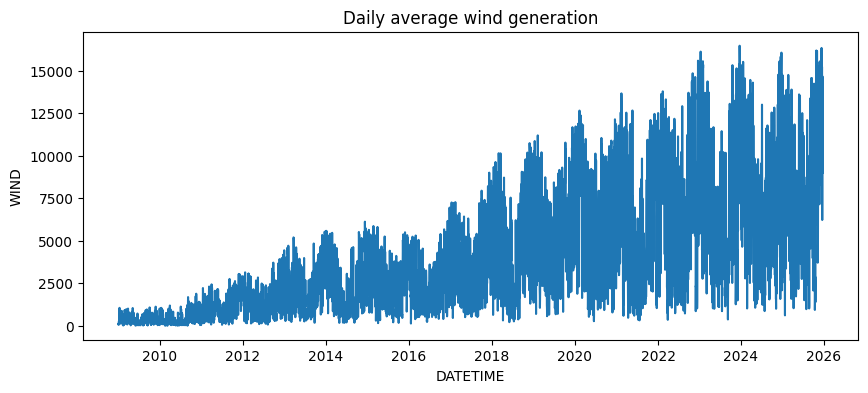

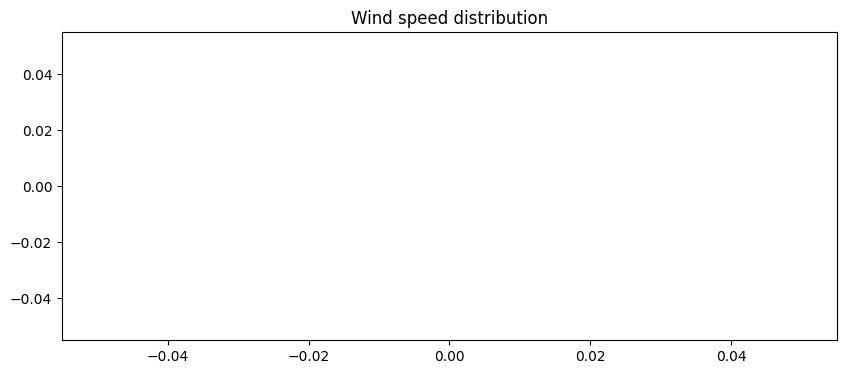

In [3]:
# quick summaries
fuel_df.head(), fuel_df.describe()

weather_df = temp_weather  # rename for convenience
print(weather_df.describe())
print(freq_sample.describe())
print(inertia_sample.describe())

# plot a few series
plt.figure(figsize=(10,4))
sns.lineplot(data=fuel_df['WIND'].resample('D').mean())
plt.title('Daily average wind generation');

plt.figure(figsize=(10,4))
sns.histplot(weather_df['Wind_Speed_100m_kph'].dropna(), bins=50)
plt.title('Wind speed distribution')

## Preprocess and Merge Data
Align timestamps, handle missing values, and join the tables on datetime index.

In [4]:
# resample or merge as needed
if GPU_ENABLED:
    # cudf/dask_cudf support for resample is limited but hourly mean works
    weather_hour = weather_df.resample('1h').mean()
    fuel_hour = fuel_df.resample('1h').mean()
    freq_hour = freq_sample.resample('1h').mean()
    inertia_hour = inertia_sample.resample('1h').mean()
    # diagnostic shapes
    print("weather_hour shape", getattr(weather_hour, 'shape', None))
    print("fuel_hour shape", getattr(fuel_hour, 'shape', None))
    print("freq_hour shape", getattr(freq_hour, 'shape', None))
    print("inertia_hour shape", getattr(inertia_hour, 'shape', None))
    # use pipeline merge for GPU-friendly concat
    merged = ml_pipeline.merge_all(weather_hour, fuel_hour, freq_hour, inertia_hour, use_gpu=True)
else:
    # ensure each dataframe has a proper datetime index before resampling
    if 'Date' in weather_df.columns:
        weather_idx = weather_df.set_index('Date')
    else:
        weather_idx = weather_df
    weather_hour = weather_idx.resample('1h').mean()

    fuel_hour = fuel_df.resample('1h').mean()

    if 'Date' in freq_sample.columns:
        freq_idx = freq_sample.set_index('Date')
    else:
        freq_idx = freq_sample
    freq_hour = freq_idx.resample('1h').mean()

    if 'DatetimeUTC' in inertia_sample.columns:
        inertia_idx = inertia_sample.set_index('DatetimeUTC')
    else:
        inertia_idx = inertia_sample
    inertia_hour = inertia_idx.resample('1h').mean()

    # diagnostic shapes
    print("weather_hour shape", weather_hour.shape)
    print("fuel_hour shape", fuel_hour.shape)
    print("freq_hour shape", freq_hour.shape)
    print("inertia_hour shape", inertia_hour.shape)

    # merge together using the pipeline helper
    merged = ml_pipeline.merge_all(fuel_hour, weather_hour, freq_hour,
                                   inertia=inertia_hour)

print("Merged shape", merged.shape)
merged.head()

weather_hour shape (0, 4)
fuel_hour shape (148786, 33)
freq_hour shape (0, 2)
inertia_hour shape (0, 5)
Merged shape (0, 44)


,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,...,Wind_Speed_100m_kph,Solar_Radiation_W_m2,year,Value,year,Settlement Date,Settlement Period,Outturn Inertia,Market Provided Inertia,year


## Feature Engineering for Temporal and Weather Features
Create additional columns from datetime and weather for use in modelling.

In [5]:
# reset index to get datetime column
merged = merged.reset_index()

# ensure there is a column named 'Date' with dtype datetime
if 'Date' not in merged.columns:
    # look for other common names produced by the loaders/merge
    for candidate in ['DatetimeUTC', 'date', 'DATE', 'index']:
        if candidate in merged.columns:
            merged.rename(columns={candidate: 'Date'}, inplace=True)
            break
    else:
        # fallback: if the original index was preserved as index after reset
        # we can take the first column and hope it's datetime
        first = merged.columns[0]
        if pd.api.types.is_datetime64_any_dtype(merged[first]):
            merged.rename(columns={first: 'Date'}, inplace=True)
        else:
            # create Date from the existing index (shouldn't normally happen)
            merged['Date'] = pd.to_datetime(merged.index)

merged['hour'] = merged['Date'].dt.hour
merged['dayofweek'] = merged['Date'].dt.dayofweek
merged['month'] = merged['Date'].dt.month
merged['season'] = (merged['month']%12 + 3)//3

# weather features already present: Temperature_C, Wind_Speed_100m_kph, Solar_Radiation_W_m2
merged[["hour","dayofweek","month","season"]].head()

,hour,dayofweek,month,season


## Train Machine Learning Models to Detect Patterns
As an example, fit a clustering model on the merged data or train a classifier to detect excursions using frequency as the label.

In [6]:

# Diagnostic check before clustering
print("Dataset shape:", merged.shape)
print("Columns available:", merged.columns.tolist())
print(merged[['Wind_Speed_100m_kph','WIND','Temperature_C']].info())
print(merged[['Wind_Speed_100m_kph','WIND','Temperature_C']].isna().sum())

# continue with clustering example below


Dataset shape: (0, 49)
Columns available: ['Date', 'GAS', 'COAL', 'NUCLEAR', 'WIND', 'WIND_EMB', 'HYDRO', 'IMPORTS', 'BIOMASS', 'OTHER', 'SOLAR', 'STORAGE', 'GENERATION', 'CARBON_INTENSITY', 'LOW_CARBON', 'ZERO_CARBON', 'RENEWABLE', 'FOSSIL', 'GAS_perc', 'COAL_perc', 'NUCLEAR_perc', 'WIND_perc', 'WIND_EMB_perc', 'HYDRO_perc', 'IMPORTS_perc', 'BIOMASS_perc', 'OTHER_perc', 'SOLAR_perc', 'STORAGE_perc', 'GENERATION_perc', 'LOW_CARBON_perc', 'ZERO_CARBON_perc', 'RENEWABLE_perc', 'FOSSIL_perc', 'Temperature_C', 'Wind_Speed_100m_kph', 'Solar_Radiation_W_m2', 'year', 'Value', 'year', 'Settlement Date', 'Settlement Period', 'Outturn Inertia', 'Market Provided Inertia', 'year', 'hour', 'dayofweek', 'month', 'season']
<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Wind_Speed_100m_kph  0 non-null      float32
 1   WIND                 0 non-null      float64
 

In [7]:
# simple clustering on weather+generation
features = merged[['Wind_Speed_100m_kph','WIND','Temperature_C']].dropna()

if features.empty:
    print("No complete rows available for clustering; skipping feature scaling/clustering.")
else:
    if GPU_ENABLED:
        from cuml.cluster import KMeans as cumlKMeans
        from cuml.preprocessing import StandardScaler as cumlScaler
        scaler = cumlScaler()
        X = scaler.fit_transform(features)
        km = cumlKMeans(n_clusters=4, random_state=0).fit(X)
        features['cluster'] = km.labels_.to_pandas() if hasattr(km.labels_, 'to_pandas') else km.labels_
    else:
        scaler = StandardScaler()
        X = scaler.fit_transform(features)
        km = KMeans(n_clusters=4, random_state=0).fit(X)
        features['cluster'] = km.labels_

    features.head()

# classification example: label rows where frequency out of 49.95-50.05
merged['freq_event'] = ((merged['Value']<49.95)|(merged['Value']>50.05)).astype(int)
clf_features = merged[['Wind_Speed_100m_kph','WIND','Temperature_C','hour','dayofweek']].dropna()
clf_labels = merged.loc[clf_features.index,'freq_event']

if clf_features.empty:
    print("No rows for classification; skipping model training.")
else:
    if GPU_ENABLED:
        from cuml.ensemble import RandomForestClassifier as cumlRF
        clf = cumlRF(n_estimators=10, random_state=1)
        # cuml expects ndarray or cudf; convert if necessary
        clf.fit(clf_features, clf_labels)
        score = clf.score(clf_features, clf_labels)
        print("Classifier score", score)
    else:
        X_train,X_test,y_train,y_test = train_test_split(clf_features, clf_labels, test_size=0.2, random_state=1)
        clf = RandomForestClassifier(n_estimators=10, random_state=1)
        clf.fit(X_train, y_train)
        print("Classifier score", clf.score(X_test, y_test))

No complete rows available for clustering; skipping feature scaling/clustering.
No rows for classification; skipping model training.


## Evaluate and Compare Model Performance
Use cross-validation and metrics to compare different approaches. (Placeholder for actual evaluation code.)

## Visualize Detected Patterns in the Data
Plot clusters or flagged events on time series to inspect where patterns occur.